In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import simpson
import csv

plt.style.use('sty.mplstyle')

In [2]:
q2_Alt = np.loadtxt('../csv/InterpolationList/Argon/40Ar_InterpolationList3pF_Altmannshofer.txt', usecols=0, delimiter=',')
u1_Alt = np.loadtxt('../csv/InterpolationList/Argon/40Ar_InterpolationList3pF_Altmannshofer.txt', usecols=1, delimiter=',')

In [3]:
HF_SKE2_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=1) # fm^{-1}
HF_SKE2_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=14)
q_HFSKE2 = HF_SKE2_xaxis*0.1973 # GeV
abs_HFSKE2 = np.abs( HF_SKE2_yaxis )

In [4]:
N2LO_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=0) # fm^{-1}
N2LO_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=1)
q_N2LO = N2LO_xaxis*0.1973 # GeV
abs_N2LO = np.abs( N2LO_yaxis )

In [5]:
RMF_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=0) # fm^{-1}
RMF_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=1)
q_RMF = RMF_xaxis*0.1973
abs_RMF = np.abs( RMF_yaxis )

In [6]:
q_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=0) # fm^{-1}
q_ShellModel = q_ShellModel*0.1973 # GeV
Fp_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=1)
Fn_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=2)
Z_aux = 18
A_aux = 40
N_aux = A_aux - Z_aux
sin2Thetaw = 0.23119
QW = (1 - 4*sin2Thetaw)*Z_aux - N_aux
Fw_ShellModel = ( (1-4*sin2Thetaw)*Z_aux*Fp_ShellModel**2 - N_aux*Fn_ShellModel**2 )/QW
abs_Fw_ShellModel = np.abs( Fw_ShellModel )

In [7]:
def Compute_u1(Q, FF):
    u1 = np.zeros_like(Q)
    for i in range(len(Q)):
        x = Q[i:]**2
        y = FF[i:]**2
        u1[i] = simpson(y,x)
    return u1

In [8]:
u1_HFSKE2_values = Compute_u1(q_HFSKE2, abs_HFSKE2)
u1_N2LO_values = Compute_u1(q_N2LO, abs_N2LO)
u1_RMF_values = Compute_u1(q_RMF, abs_RMF)
u1_ShellModel_values = Compute_u1(q_ShellModel, abs_Fw_ShellModel)

In [9]:
def Give_me_u1Cpp(q2, u1, q2_ref):
    if (q2_ref > q2.max()):
        u1_aux = 0
    elif ( q2.min() <= q2_ref ):
        q2_left = q2[q2<=q2_ref]
        u1_left = u1[q2<=q2_ref]
        q2_right = q2[q2>q2_ref]
        u1_right = u1[q2>q2_ref]
        slope = ( u1_right[0] - u1_left[-1] )/( q2_right[0] - q2_left[-1] )
        u1_aux = slope*(q2_ref - q2_left[-1]) + u1_left[-1]
    else:
        q2_min = q2[0]
        q2_max = q2[1]
        u1_min = u1[0]
        u1_max = u1[1]
        slope = ( u1_max - u1_min )/ ( q2_max - q2_min )
        u1_aux = slope*(0 - q2_min) + u1_min
    return u1_aux

In [10]:
u1Cpp_HFSKE2 = 5*np.ones_like(q2_Alt)
for index in range(len(q2_Alt)):
    u1Cpp_HFSKE2[index] = Give_me_u1Cpp(q_HFSKE2**2, u1_HFSKE2_values, q2_Alt[index])

# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_HFSKE2_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1Cpp_HFSKE2):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

In [11]:
u1Cpp_N2LO = 5*np.ones_like(q2_Alt)
for index in range(len(q2_Alt)):
    u1Cpp_N2LO[index] = Give_me_u1Cpp(q_N2LO**2, u1_N2LO_values, q2_Alt[index])

# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_N2LO_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1Cpp_N2LO):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

In [12]:
u1Cpp_RMF = 5*np.ones_like(q2_Alt)
for index in range(len(q2_Alt)):
    u1Cpp_RMF[index] = Give_me_u1Cpp(q_RMF**2, u1_RMF_values, q2_Alt[index])

# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_RMF_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1Cpp_RMF):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

In [13]:
u1Cpp_ShellModel = 5*np.ones_like(q2_Alt)
for index in range(len(q2_Alt)):
    u1Cpp_ShellModel[index] = Give_me_u1Cpp(q_ShellModel**2, u1_ShellModel_values, q2_Alt[index])

# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_ShellModel_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1Cpp_ShellModel):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

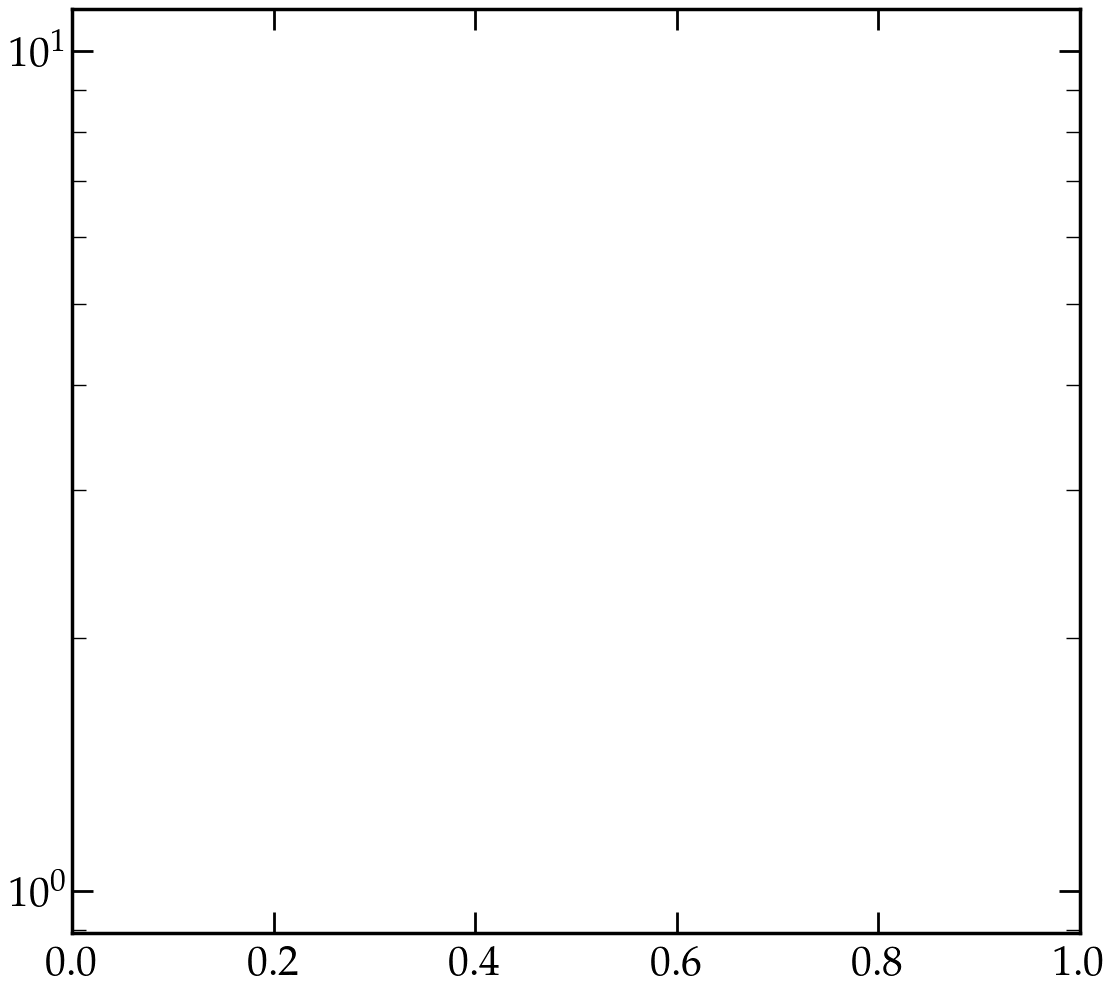

In [23]:
fig = plt.figure()
ax = fig.add_subplot()

#ax.plot(q2_Alt, u1_Alt, color='red')

#ax.plot(q_HFSKE2**2, u1_HFSKE2_values, color='blue')
#ax.plot(q2_Alt, u1Cpp_HFSKE2, color='green')

#ax.plot(q_N2LO**2, u1_N2LO_values, color='blue')
#ax.plot(q2_Alt, u1Cpp_N2LO, color='green')

#ax.plot(q_RMF**2, u1_RMF_values, color='blue')
#ax.plot(q2_Alt, u1Cpp_RMF, color='green')

#ax.plot(q_ShellModel**2, u1_ShellModel_values, color='blue')
#ax.plot(q2_Alt, u1Cpp_ShellModel, color='green')
#ax.set_xlim([-0.001,0.04])

ax.set_yscale('log')